In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [2]:
df = pd.read_csv("..\Datasets\wholesale+customers-Clustering Dataset\Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


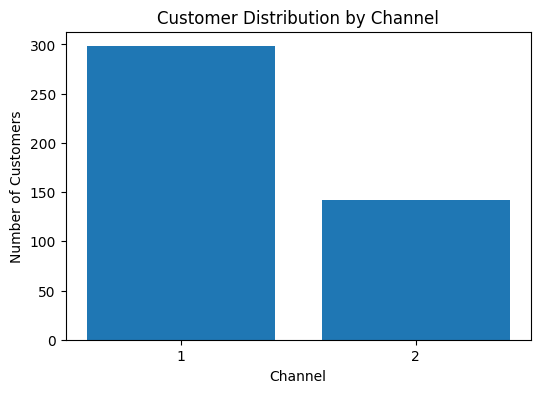

In [5]:
channel_count = df["Channel"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(channel_count.index.astype(str), channel_count.values)
plt.title("Customer Distribution by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Customers")
plt.show()

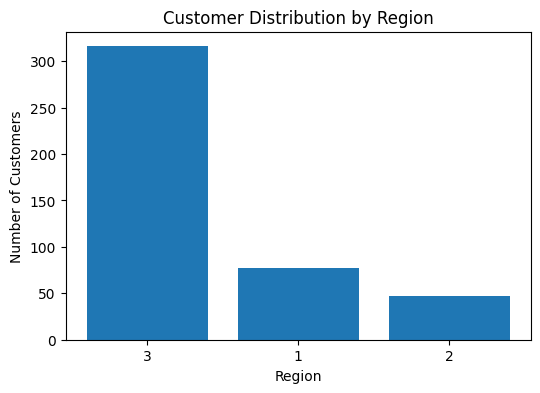

In [6]:
region_count = df["Region"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(region_count.index.astype(str), region_count.values)
plt.title("Customer Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.show()

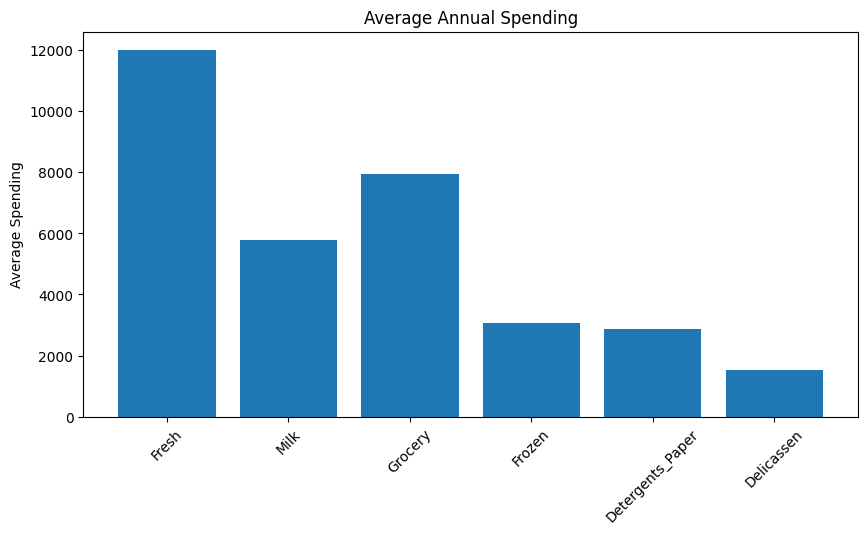

In [7]:
avg_spending = df[
    [
        "Fresh",
        "Milk",
        "Grocery",
        "Frozen",
        "Detergents_Paper",
        "Delicassen"
    ]
].mean()

plt.figure(figsize=(10,5))
plt.bar(avg_spending.index, avg_spending.values)
plt.xticks(rotation=45)
plt.title("Average Annual Spending")
plt.ylabel("Average Spending")
plt.show()

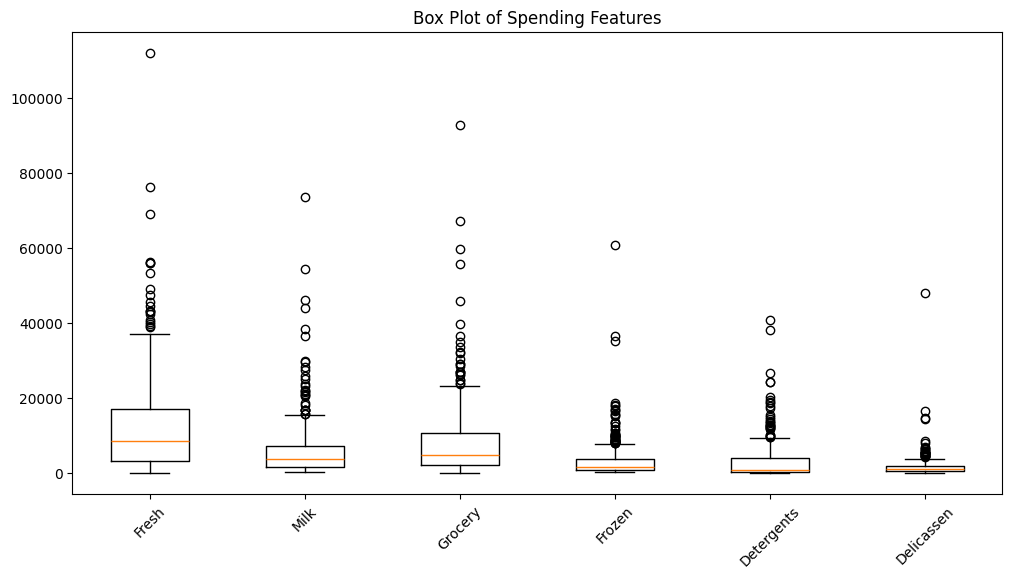

In [8]:
plt.figure(figsize=(12,6))

plt.boxplot(
    df[
        [
            "Fresh",
            "Milk",
            "Grocery",
            "Frozen",
            "Detergents_Paper",
            "Delicassen"
        ]
    ]
)

plt.xticks(
    range(1,7),
    [
        "Fresh",
        "Milk",
        "Grocery",
        "Frozen",
        "Detergents",
        "Delicassen"
    ],
    rotation=45
)

plt.title("Box Plot of Spending Features")

plt.show()

In [9]:
X = df

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
K_mean = KMeans(
    n_clusters=3,
    random_state=42
)

K_mean.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [12]:
labels = K_mean.predict(X_scaled)
print(labels)

[0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 1 2 0 0 1 1 0 1 1 1 1 1 1 0 1
 0 0 1 1 1 0 0 0 0 0 2 0 0 1 1 0 0 1 1 2 0 1 1 0 2 0 0 1 2 1 0 1 1 1 1 1 0
 0 1 1 0 1 1 1 0 0 1 0 2 2 1 1 1 1 1 2 1 0 1 0 1 1 1 0 0 0 1 1 1 0 0 0 0 1
 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 2 1 2 1
 1 1 1 0 0 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 0 1 0 1 0 1 2 1 1 0 1 0 1 0 1 1 1
 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 2 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0
 1 0 0 1 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1
 2 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1
 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 1 1 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]


In [13]:
df['Cluster'] = labels

cluster_summary = df.groupby("Cluster").mean()
print(cluster_summary)

          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        2.000000  2.623077   8165.915385   8748.515385  13905.492308   
1        1.003367  2.505051  13075.898990   3218.737374   3855.696970   
2        1.846154  2.615385  25770.769231  35160.384615  41977.384615   

              Frozen  Detergents_Paper   Delicassen  
Cluster                                              
0        1441.630769       5991.146154  1535.007692  
1        3620.400673        776.875421  1242.249158  
2        6844.538462      19867.384615  7880.307692  


In [14]:
# inertia measures how close the data points are to their cluster centroid
inertia = K_mean.inertia_

# Silhouette Score measures: How close a point is to its own cluster, How far it is from other clusters.
silhouette = silhouette_score(X_scaled,K_mean.labels_)

# Measures the similarity between clusters
dbi = davies_bouldin_score(X_scaled,K_mean.labels_)

# Measures: Distance between clusters, Compactness within clusters
chi = calinski_harabasz_score(X_scaled,K_mean.labels_)

print("Inertia (WCSS):", inertia)
print("Silhouette Score:", silhouette)
print("Davies-Bouldin Index:", dbi)
print("Calinski-Harabasz Index:", chi)

Inertia (WCSS): 2149.283956221759
Silhouette Score: 0.3567685389017652
Davies-Bouldin Index: 1.1736367961162066
Calinski-Harabasz Index: 139.34941202094197


In [15]:
new_customer = [[1, 2, 15000, 8000, 6000, 500, 2000, 1000]]

new_customer_scaled = scaler.transform(new_customer)

cluster = K_mean.predict(new_customer_scaled)[0]

print(cluster)

1


C:\Users\aravi\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
cluster_labels = {
    0: "Poor",
    1: "Medium",
    2: "Rich"
}

df["Customer_Category"] = df["Cluster"].map(cluster_labels)

print(df[["Cluster", "Customer_Category"]].head())

   Cluster Customer_Category
0        0              Poor
1        0              Poor
2        0              Poor
3        1            Medium
4        0              Poor


In [17]:
print("Customer Category:", cluster_labels[cluster])

Customer Category: Medium


In [18]:
customer_details= {
    "Channel": 1,
    "Region": 3,
    "Fresh": 22615,
    "Milk": 5410,
    "Grocery": 7198,
    "Frozen": 3915,
    "Detergents_Paper": 1777,
    "Delicassen": 5185
}
new_customer_scaled = scaler.transform(new_customer)
cluster = K_mean.predict(new_customer_scaled)[0]

cluster_labels = {
    0: "Poor",
    1: "Medium",
    2: "Rich"
}
customer_category = cluster_labels[cluster]

C:\Users\aravi\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [19]:
from google import genai
from google.genai import types
import os
from dotenv import load_dotenv

load_dotenv()

client = genai.Client(api_key=os.getenv("Gemini_api_key"))

def get_response(prompt, model="gemini-3.1-flash-lite"):
    response = client.models.generate_content(
        model=model,
        contents=prompt,
        config=types.GenerateContentConfig(
            thinking_config=types.ThinkingConfig(thinking_level="high"),
            temperature=0.2
        )
    )
    return response.text

In [20]:
prompt = f"""
you are expert in finanical advising.

customer details: {customer_details}

cusromer category: {customer_category}

Provide:
    1. Financial status analysis
    2. Spending behavior insights
    3. Savings recommendations
    4. Investment suggestions
    5. Risk level
    6. Future financial improvement plan

Give the response in bullet points.
"""

In [21]:
print(get_response(prompt))

Based on the data provided, your business profile (Channel 1, likely Horeca/Hospitality) indicates a stable, mid-sized operation with a heavy reliance on perishable inventory. Here is your financial analysis and strategic roadmap:

### 1. Financial Status Analysis
*   **Total Expenditure:** Your total spending across these categories is 46,100 units.
*   **Inventory Concentration:** Nearly 50% of your total spending (22,615) is allocated to "Fresh" products. This indicates a business model heavily dependent on high-turnover, perishable goods, typical of a restaurant or catering service.
*   **Operational Stability:** Being categorized as "Medium" suggests you have moved past the startup phase and have established a consistent, predictable cash flow pattern.
*   **Cost Structure:** Your spending is heavily skewed toward raw materials (Fresh, Milk, Grocery), which indicates that your primary financial burden is Cost of Goods Sold (COGS) rather than overhead or administrative expenses.

#

In [23]:
import markdown
from IPython.display import HTML, display

html_format = markdown.markdown(get_response(prompt))
display(HTML(html_format))

In [24]:
import pickle

with open("cluster_model.pkl", "wb") as f:
    pickle.dump(K_mean,f)
    
with open("Cluster_scaler.pkl", "wb") as f:
    pickle.dump(scaler,f)